# Assignment #1 — Question 2: English → Urdu NMT using a Vanilla RNN

This notebook implements Question 2 end-to-end: preprocessing, reproducible 80/10/10 splitting, word-level tokenization, vocabularies with special tokens, padding/masking/batching, a Vanilla RNN encoder–decoder, training with gradient clipping, checkpointing, early stopping, training/validation curves, and qualitative translations.

The assignment specifies the Kaggle `translation-dataset` (~24k parallel English–Urdu pairs) and requires Vanilla RNN layers only — no LSTM, GRU, attention, or Transformer components. fileciteturn0file0L33-L55

**Important:** Run this notebook on **Kaggle with Internet enabled**. It downloads the dataset automatically; you do not need to attach the dataset manually.

In [1]:
# ============================================================
# 0. INSTALL / IMPORTS / REPRODUCIBILITY
# ============================================================

!pip -q install -U kagglehub

import os
import re
import glob
import random
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU(s):", tf.config.list_physical_devices("GPU"))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 14.7 MB/s eta 0:00:00
TensorFlow: 2.20.0
GPU(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 1. Download the Kaggle dataset automatically

The assignment specifies:

`muhammadnoman76/translation-dataset`

No manual upload is required. `kagglehub.dataset_download()` downloads the public dataset directly into the Kaggle runtime. fileciteturn0file0L33-L36

In [2]:
# ============================================================
# 1. DOWNLOAD DATASET FROM KAGGLE
# ============================================================

DATASET_HANDLE = "muhammadnoman76/translation-dataset"

print("Downloading Kaggle dataset...")
dataset_dir = Path(kagglehub.dataset_download(DATASET_HANDLE))

print("Dataset directory:", dataset_dir)

all_files = [p for p in dataset_dir.rglob("*") if p.is_file()]

print("\nDownloaded files:")
for p in all_files:
    print(" -", p)

data_files = [
    p for p in all_files
    if p.suffix.lower() in {".csv", ".tsv", ".txt", ".xlsx", ".json"}
]

if not data_files:
    raise FileNotFoundError(
        "No CSV/TSV/TXT/XLSX/JSON data file was found in the downloaded Kaggle dataset."
    )

Dataset directory: /kaggle/input/datasets/muhammadnoman76/translation-dataset

Downloaded files:
 - /kaggle/input/datasets/muhammadnoman76/translation-dataset/english_to_urdu_dataset.xlsx


In [3]:
# ============================================================
# 2. ROBUST DATA LOADING + ENGLISH/URDU COLUMN DETECTION
# ============================================================

def read_table(path):
    suffix = path.suffix.lower()

    if suffix == ".csv":
        for sep in [",", "\t", ";", "|"]:
            try:
                tmp = pd.read_csv(path, sep=sep, engine="python")
                if tmp.shape[1] >= 2 and len(tmp) > 0:
                    return tmp
            except Exception:
                pass
        raise ValueError(f"Could not parse {path}")

    if suffix == ".tsv":
        return pd.read_csv(path, sep="\t", engine="python")

    if suffix == ".xlsx":
        return pd.read_excel(path)

    if suffix == ".json":
        return pd.read_json(path)

    if suffix == ".txt":
        return pd.read_csv(
            path, sep="\t", header=None,
            names=["English", "Urdu"], engine="python"
        )

    raise ValueError(path)


def score_column(name, language):
    s = str(name).strip().lower()

    if language == "en":
        keywords = ["english", "eng", "source", "sentence1", "input"]
    else:
        keywords = ["urdu", "target", "translation", "sentence2"]

    return sum(k in s for k in keywords)


def detect_columns(df):
    cols = list(df.columns)

    en_scores = sorted(
        [(score_column(c, "en"), c) for c in cols],
        reverse=True
    )
    ur_scores = sorted(
        [(score_column(c, "ur"), c) for c in cols],
        reverse=True
    )

    en_col = en_scores[0][1] if en_scores[0][0] > 0 else None
    ur_col = ur_scores[0][1] if ur_scores[0][0] > 0 else None

    if en_col is not None and ur_col is not None and en_col != ur_col:
        return en_col, ur_col

    # Fallback: choose two text-like columns.
    candidates = []

    for c in cols:
        values = df[c].dropna().astype(str)

        if len(values) == 0:
            continue

        avg_length = values.str.len().mean()
        unique_ratio = values.nunique() / max(1, len(values))

        candidates.append((avg_length * unique_ratio, c))

    candidates.sort(reverse=True)

    if len(candidates) < 2:
        raise ValueError(
            f"Could not detect two text columns. Found: {cols}"
        )

    return candidates[0][1], candidates[1][1]


loaded = []

for path in data_files:
    try:
        tmp = read_table(path)

        if tmp.shape[1] >= 2 and len(tmp) > 10:
            loaded.append((len(tmp), path, tmp))

    except Exception as e:
        print("Skipping", path.name, "->", e)

if not loaded:
    raise RuntimeError("No usable parallel dataset file was found.")

_, source_file, raw_df = max(loaded, key=lambda x: x[0])

print("Selected file:", source_file)
print("Shape:", raw_df.shape)
print("Columns:", list(raw_df.columns))

EN_COL, UR_COL = detect_columns(raw_df)

print("Detected English column:", EN_COL)
print("Detected Urdu column:", UR_COL)

df = raw_df[[EN_COL, UR_COL]].copy()
df.columns = ["english", "urdu"]

display(df.head())

Selected file: /kaggle/input/datasets/muhammadnoman76/translation-dataset/english_to_urdu_dataset.xlsx
Shape: (9103, 2)
Columns: ['eng', 'urdu']
Detected English column: eng
Detected Urdu column: urdu


,english,urdu
0,the book of the generation of jesus christ th...,یسوع مسیح ابن داود ابن ابرہام کا نسب نامہ
1,abraham begat isaac and isaac begat jacob an...,ابراہام سے اضحاق پیدا ہوا اور اضحاق سے یعقوب پ...
2,and judas begat phares and zara of thamar and...,اور یہوداہ سے فارص اور زارح تمر سے پیدا ہوئے ا...
3,and aram begat aminadab and aminadab begat na...,اور رام سے عمینداب پیدا ہوا اور عمینداب سے نحس...
4,and salmon begat booz of rachab and booz bega...,اور سلمون سے بوعز راحب سے پیدا ہوا اور بوعز سے...


## 2. Preprocessing

The assignment requires inspection of structure/length distributions and preprocessing for both languages, including punctuation and whitespace normalization, Urdu Unicode normalization, removal of corrupted/empty samples, and optional length filtering. fileciteturn0file0L40-L42

In [4]:
# ============================================================
# 3. TEXT NORMALIZATION / CLEANING
# ============================================================

def normalize_english(text):
    text = unicodedata.normalize("NFKC", str(text))

    text = (
        text.replace("“", '"')
            .replace("”", '"')
            .replace("’", "'")
            .replace("‘", "'")
    )

    text = re.sub(r"\s+", " ", text).strip()

    return text


def normalize_urdu(text):
    # NFC preserves Urdu characters while normalizing Unicode representation.
    text = unicodedata.normalize("NFC", str(text))

    # Remove zero-width joiner/non-joiner artifacts as standalone whitespace.
    text = text.replace("\u200c", " ").replace("\u200d", " ")

    text = re.sub(r"\s+", " ", text).strip()

    return text


df["english"] = df["english"].map(normalize_english)
df["urdu"] = df["urdu"].map(normalize_urdu)

before = len(df)

# Remove missing and empty rows.
df = df.dropna().copy()
df = df[
    (df["english"].str.len() > 0) &
    (df["urdu"].str.len() > 0)
]

# Remove accidental header rows if present.
df = df[
    ~df["english"].str.lower().isin(["english", "source"])
]
df = df[
    ~df["urdu"].str.lower().isin(["urdu", "target", "translation"])
]

# Remove exact duplicate parallel pairs.
df = df.drop_duplicates(
    subset=["english", "urdu"]
).reset_index(drop=True)


def word_count(text):
    return len(text.split())


df["en_len"] = df["english"].map(word_count)
df["ur_len"] = df["urdu"].map(word_count)

# Optional length filtering: remove extreme outliers.
MAX_RAW_EN = 40
MAX_RAW_UR = 50

df = df[
    (df["en_len"] >= 1) &
    (df["ur_len"] >= 1) &
    (df["en_len"] <= MAX_RAW_EN) &
    (df["ur_len"] <= MAX_RAW_UR)
].reset_index(drop=True)

print(f"Rows before cleaning:       {before:,}")
print(f"Rows after cleaning:        {len(df):,}")
print(f"Rows removed:               {before - len(df):,}")

print("\nSample parallel pairs:")
display(
    df[["english", "urdu"]].sample(
        min(10, len(df)), random_state=SEED
    )
)

Rows before cleaning:       9,103
Rows after cleaning:        8,828
Rows removed:               275

Sample parallel pairs:


,english,urdu
1010,and many women were there beholding afar off w...,اور وہاں بہت سی عورتیں جو گلیل سے یسوع کی خدمت...
6234,and ye became followers of us and of the lord ...,اور تم کلام کو بڑی مصیبت میں روح القدس کی خوشخ...
8763,"My uncle went to Mexico in 1983, never to come...",میرے تایا ۱۹۸۳ میں میکسیکو گئے تھے اور کبھی وا...
6463,and having food and raiment let us be therewit...,پس اگر ہمارے پاس کھانے پہننے کو ہے تو اسی پر ق...
8624,Could you put your seat back up a little?,آپ اپنی سیٹ تھوڑی اوپر کر سکتے ہے؟
1295,and when he had called all the people unto him...,اور وہ لوگوں کو پھر پاس بلاکر ان سے کہنے لگا ت...
2826,he was in the world and the world was made by ...,وہ دنیا میں تھا اور دنیا اس کے وسیلہ سے پیدا ہ...
932,and behold one of them which were with jesus s...,اور دیکھو یسوع کے ساتھیوں میں سے ایک نے ہاتھ ب...
3404,peter saith unto him thou shalt never wash my ...,پطرس نے اس سے کہا کہ تو میرے پاوں ابد تک کبھی ...
8446,Our teacher told us when to start.,ہماری استانی نے ہمیں بتایا کہ کب شروع کرنا ہے۔


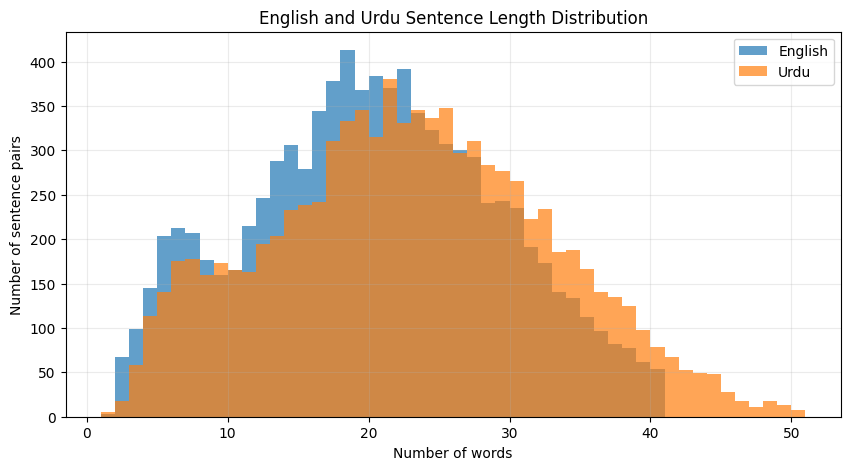

,en_len,ur_len
count,8828.00,8828.00
mean,19.89,22.43
std,8.85,9.84
min,1.00,1.00
25%,14.00,15.00
50%,20.00,22.00
75%,26.00,29.00
max,40.00,50.00


In [5]:
# ============================================================
# 4. SENTENCE LENGTH DISTRIBUTIONS
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    df["en_len"],
    bins=range(1, MAX_RAW_EN + 2),
    alpha=0.7,
    label="English"
)

plt.hist(
    df["ur_len"],
    bins=range(1, MAX_RAW_UR + 2),
    alpha=0.7,
    label="Urdu"
)

plt.title("English and Urdu Sentence Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Number of sentence pairs")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

display(
    df[["en_len", "ur_len"]]
    .describe()
    .round(2)
)

## 3. Reproducible 80/10/10 split and leakage check

A fixed seed of **42** is used. The split is performed after cleaning, and exact English–Urdu pair overlap is checked between all three partitions. This satisfies the assignment's reproducible 80/10/10 requirement. fileciteturn0file0L43-L43

In [6]:
# ============================================================
# 5. 80 / 10 / 10 SPLIT
# ============================================================

shuffled = df.sample(
    frac=1.0,
    random_state=SEED
).reset_index(drop=True)

n = len(shuffled)

n_train = int(0.80 * n)
n_val = int(0.10 * n)

train_df = shuffled.iloc[:n_train].copy()
val_df = shuffled.iloc[n_train:n_train + n_val].copy()
test_df = shuffled.iloc[n_train + n_val:].copy()

print(f"Train      : {len(train_df):,} ({len(train_df)/n:.1%})")
print(f"Validation : {len(val_df):,} ({len(val_df)/n:.1%})")
print(f"Test       : {len(test_df):,} ({len(test_df)/n:.1%})")
print(f"Total      : {n:,}")


def pair_set(frame):
    return set(zip(frame["english"], frame["urdu"]))


train_pairs = pair_set(train_df)
val_pairs = pair_set(val_df)
test_pairs = pair_set(test_df)

print("\nExact pair overlap:")
print("Train ∩ Validation:", len(train_pairs & val_pairs))
print("Train ∩ Test       :", len(train_pairs & test_pairs))
print("Validation ∩ Test  :", len(val_pairs & test_pairs))

assert not (train_pairs & val_pairs)
assert not (train_pairs & test_pairs)
assert not (val_pairs & test_pairs)

print("\n✓ No exact parallel-pair leakage detected.")

Train      : 7,062 (80.0%)
Validation : 882 (10.0%)
Test       : 884 (10.0%)
Total      : 8,828

Exact pair overlap:
Train ∩ Validation: 0
Train ∩ Test       : 0
Validation ∩ Test  : 0

✓ No exact parallel-pair leakage detected.


In [7]:
# ============================================================
# 6. SPLIT SUMMARY
# ============================================================

split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Pairs": [
        len(train_df),
        len(val_df),
        len(test_df)
    ],
    "Percentage": [
        len(train_df) / n * 100,
        len(val_df) / n * 100,
        len(test_df) / n * 100
    ],
    "Avg English words": [
        train_df.en_len.mean(),
        val_df.en_len.mean(),
        test_df.en_len.mean()
    ],
    "Avg Urdu words": [
        train_df.ur_len.mean(),
        val_df.ur_len.mean(),
        test_df.ur_len.mean()
    ]
})

display(split_summary.round(2))

,Split,Pairs,Percentage,Avg English words,Avg Urdu words
0,Train,7062,80.00,19.79,22.35
1,Validation,882,9.99,20.59,23.03
2,Test,884,10.01,20.02,22.51


## 4. Word-level tokenization and vocabularies

The assignment requires word-level tokenization for both languages and vocabularies containing padding, beginning-of-sentence, and end-of-sentence symbols. fileciteturn0file0L44-L46

Punctuation is retained as separate tokens so that the model can learn punctuation patterns.

In [8]:
# ============================================================
# 7. WORD-LEVEL TOKENIZER + VOCABULARIES
# ============================================================

TOKEN_PATTERN = re.compile(
    r"[\w\u0600-\u06FF]+|[^\w\s]",
    re.UNICODE
)

def tokenize(text):
    return TOKEN_PATTERN.findall(str(text))


SPECIALS = ["<PAD>", "<BOS>", "<EOS>", "<UNK>"]

PAD_ID = 0
BOS_ID = 1
EOS_ID = 2
UNK_ID = 3


def build_vocab(texts, min_freq=1):
    frequencies = {}

    for text in texts:
        for token in tokenize(text):
            frequencies[token] = frequencies.get(token, 0) + 1

    ordered = sorted(
        frequencies.items(),
        key=lambda x: (-x[1], x[0])
    )

    vocab = {
        token: idx
        for idx, token in enumerate(SPECIALS)
    }

    for token, count in ordered:
        if count >= min_freq and token not in vocab:
            vocab[token] = len(vocab)

    return vocab, frequencies


# IMPORTANT: build vocabularies from TRAINING data only.
en_vocab, en_freq = build_vocab(train_df["english"])
ur_vocab, ur_freq = build_vocab(train_df["urdu"])

en_id_to_token = {
    idx: token for token, idx in en_vocab.items()
}

ur_id_to_token = {
    idx: token for token, idx in ur_vocab.items()
}

print("English vocabulary size:", len(en_vocab))
print("Urdu vocabulary size   :", len(ur_vocab))

print("\nEnglish special tokens:")
print({s: en_vocab[s] for s in SPECIALS})

print("\nUrdu special tokens:")
print({s: ur_vocab[s] for s in SPECIALS})

English vocabulary size: 6039
Urdu vocabulary size   : 7182

English special tokens:
{'<PAD>': 0, '<BOS>': 1, '<EOS>': 2, '<UNK>': 3}

Urdu special tokens:
{'<PAD>': 0, '<BOS>': 1, '<EOS>': 2, '<UNK>': 3}


In [9]:
# ============================================================
# 8. TOKENIZE + INTEGER ENCODE
# ============================================================

def encode_source(text, vocab):
    return [
        vocab.get(token, UNK_ID)
        for token in tokenize(text)
    ]


def encode_target(text, vocab):
    # Target: <BOS> token1 token2 ... tokenN <EOS>
    return (
        [BOS_ID]
        + [vocab.get(token, UNK_ID) for token in tokenize(text)]
        + [EOS_ID]
    )


def encode_frame(frame):
    source_sequences = [
        encode_source(text, en_vocab)
        for text in frame["english"]
    ]

    target_sequences = [
        encode_target(text, ur_vocab)
        for text in frame["urdu"]
    ]

    return source_sequences, target_sequences


train_src, train_tgt = encode_frame(train_df)
val_src, val_tgt = encode_frame(val_df)
test_src, test_tgt = encode_frame(test_df)

print("Example English tokens:")
print(tokenize(train_df.iloc[0]["english"]))

print("\nExample Urdu tokens:")
print(tokenize(train_df.iloc[0]["urdu"]))

print("\nEncoded source:")
print(train_src[0])

print("\nEncoded target:")
print(train_tgt[0])

Example English tokens:
['and', 'many', 'women', 'were', 'there', 'beholding', 'afar', 'off', 'which', 'followed', 'jesus', 'from', 'galilee', 'ministering', 'unto', 'him']

Example Urdu tokens:
['اور', 'وہاں', 'بہت', 'سی', 'عورتیں', 'جو', 'گلیل', 'سے', 'یسوع', 'کی', 'خدمت', 'کرتی', 'ہوئی', 'اس', 'کے', 'پیچھے', 'پیچھے', 'آئی', 'تھیں', 'دور', 'سے', 'دیکھ', 'رہی', 'تھیں', '۔']

Encoded source:
[5, 100, 415, 45, 55, 1080, 779, 307, 24, 336, 36, 46, 317, 1630, 12, 11]

Encoded target:
[1, 5, 138, 83, 379, 1028, 18, 397, 7, 38, 11, 241, 431, 137, 9, 6, 187, 187, 375, 275, 355, 7, 134, 360, 275, 4, 2]


## 5. Sequence encoding, padding, masks, and batching

Encoder input, decoder input, and shifted target output are prepared separately. Padding is represented by `<PAD> = 0`. The target mask makes padded positions contribute **zero** to the loss, satisfying the assignment's masking requirement. fileciteturn0file0L49-L51

In [10]:
# ============================================================
# 9. PADDING + SHIFTED TARGETS + MASKS
# ============================================================

MAX_EN_LEN = max(
    len(x)
    for x in train_src + val_src + test_src
)

MAX_UR_LEN = max(
    len(x)
    for x in train_tgt + val_tgt + test_tgt
)


def pad_sequences_custom(sequences, max_len):
    output = np.full(
        (len(sequences), max_len),
        PAD_ID,
        dtype=np.int32
    )

    for i, sequence in enumerate(sequences):
        length = min(len(sequence), max_len)
        output[i, :length] = sequence[:length]

    return output


def make_arrays(source_sequences, target_sequences):
    encoder_input = pad_sequences_custom(
        source_sequences,
        MAX_EN_LEN
    )

    full_target = pad_sequences_custom(
        target_sequences,
        MAX_UR_LEN
    )

    # Teacher forcing:
    # decoder input  = <BOS> token1 token2 ...
    # target output   = token1 token2 ... <EOS>
    decoder_input = full_target[:, :-1]
    target_output = full_target[:, 1:]

    target_mask = (
        target_output != PAD_ID
    ).astype(np.float32)

    return (
        encoder_input,
        decoder_input,
        target_output,
        target_mask
    )


X_train, D_train, Y_train, M_train = make_arrays(
    train_src, train_tgt
)

X_val, D_val, Y_val, M_val = make_arrays(
    val_src, val_tgt
)

X_test, D_test, Y_test, M_test = make_arrays(
    test_src, test_tgt
)

print("Encoder input :", X_train.shape)
print("Decoder input :", D_train.shape)
print("Target output :", Y_train.shape)
print("Target mask   :", M_train.shape)

print("\nMaximum English length:", MAX_EN_LEN)
print("Maximum Urdu length   :", MAX_UR_LEN)

Encoder input : (7062, 40)
Decoder input : (7062, 51)
Target output : (7062, 51)
Target mask   : (7062, 51)

Maximum English length: 40
Maximum Urdu length   : 52


In [11]:
# ============================================================
# 10. TF.DATA BATCHING
# ============================================================

BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE


def make_dataset(X, D, Y, M, training=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        ((X, D), Y, M)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(X),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    return (
        dataset
        .batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)
    )


train_ds = make_dataset(
    X_train, D_train, Y_train, M_train, True
)

val_ds = make_dataset(
    X_val, D_val, Y_val, M_val, False
)

test_ds = make_dataset(
    X_test, D_test, Y_test, M_test, False
)

print(
    "Training batches:",
    tf.data.experimental.cardinality(train_ds).numpy()
)

I0000 00:00:1789496192.686668      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789496192.690148      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Training batches: 111


## 6. Primary model — Vanilla RNN Encoder–Decoder

The model uses `tf.keras.layers.SimpleRNN` for both encoder and decoder. There is **no LSTM, GRU, attention, or Transformer**.

Architecture:

**English IDs → Embedding → Vanilla RNN Encoder → final hidden state → Vanilla RNN Decoder → Dense Softmax → Urdu token probabilities**

The encoder final state initializes the decoder, which is the standard simple encoder–decoder approach without attention.

In [12]:
# ============================================================
# 11. VANILLA RNN ENCODER–DECODER
# ============================================================

EMBED_DIM = 128
RNN_UNITS = 256
DROPOUT = 0.20
LEARNING_RATE = 1e-3


class VanillaRNMT(tf.keras.Model):

    def __init__(
        self,
        en_vocab_size,
        ur_vocab_size,
        embed_dim=128,
        rnn_units=256,
        dropout=0.20
    ):
        super().__init__()

        self.encoder_embedding = tf.keras.layers.Embedding(
            input_dim=en_vocab_size,
            output_dim=embed_dim,
            mask_zero=True,
            name="encoder_embedding"
        )

        self.encoder_rnn = tf.keras.layers.SimpleRNN(
            units=rnn_units,
            return_sequences=False,
            return_state=True,
            dropout=dropout,
            name="vanilla_rnn_encoder"
        )

        self.decoder_embedding = tf.keras.layers.Embedding(
            input_dim=ur_vocab_size,
            output_dim=embed_dim,
            mask_zero=True,
            name="decoder_embedding"
        )

        self.decoder_rnn = tf.keras.layers.SimpleRNN(
            units=rnn_units,
            return_sequences=True,
            return_state=True,
            dropout=dropout,
            name="vanilla_rnn_decoder"
        )

        self.output_layer = tf.keras.layers.Dense(
            units=ur_vocab_size,
            activation="softmax",
            name="urdu_token_classifier"
        )


    def call(self, inputs, training=False):

        encoder_input, decoder_input = inputs

        # Encoder
        enc_embedding = self.encoder_embedding(
            encoder_input
        )

        _, encoder_state = self.encoder_rnn(
            enc_embedding,
            training=training
        )

        # Decoder starts from encoder's final hidden state.
        dec_embedding = self.decoder_embedding(
            decoder_input
        )

        decoder_sequence, _ = self.decoder_rnn(
            dec_embedding,
            initial_state=encoder_state,
            training=training
        )

        # Next-token probability distribution.
        return self.output_layer(decoder_sequence)


model = VanillaRNMT(
    en_vocab_size=len(en_vocab),
    ur_vocab_size=len(ur_vocab),
    embed_dim=EMBED_DIM,
    rnn_units=RNN_UNITS,
    dropout=DROPOUT
)

# Build the model once.
dummy_encoder = tf.zeros(
    (2, MAX_EN_LEN),
    dtype=tf.int32
)

dummy_decoder = tf.zeros(
    (2, MAX_UR_LEN - 1),
    dtype=tf.int32
)

_ = model(
    (dummy_encoder, dummy_decoder),
    training=False
)

model.summary()

Model: "vanilla_rnmt"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_embedding (Embedding)   │ (2, 40, 128)           │       772,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vanilla_rnn_encoder (SimpleRNN) │ ((2, 256), (2, 256))   │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_embedding (Embedding)   │ (2, 51, 128)           │       919,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vanilla_rnn_decoder (SimpleRNN) │ ((2, 51, 256), (2,     │        98,560 │
│                                 │ 256))                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ urdu_token_classifier (Dense)   │ (2, 51, 7182)          │     1,845,774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,735,182 (14.25 MB)

 Trainable params: 3,735,182 (14.25 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# ============================================================
# 12. LAYER TABLE
# ============================================================

layer_rows = []

for layer in model.layers:

    try:
        output_shape = str(layer.output_shape)
    except Exception:
        output_shape = "Built dynamically"

    layer_rows.append({
        "Layer": layer.name,
        "Type": layer.__class__.__name__,
        "Parameters": layer.count_params(),
        "Output shape": output_shape
    })

layer_table = pd.DataFrame(layer_rows)

display(layer_table)

print(
    "Total parameters:",
    f"{model.count_params():,}"
)

,Layer,Type,Parameters,Output shape
0,encoder_embedding,Embedding,772992,Built dynamically
1,vanilla_rnn_encoder,SimpleRNN,98560,Built dynamically
2,decoder_embedding,Embedding,919296,Built dynamically
3,vanilla_rnn_decoder,SimpleRNN,98560,Built dynamically
4,urdu_token_classifier,Dense,1845774,Built dynamically


Total parameters: 3,735,182


## 7. Training pipeline

The assignment requires loss computation, optimization, gradient clipping, checkpoint saving, suitable hyperparameters, and monitoring of training/validation loss. fileciteturn0file0L52-L55

In [14]:
# ============================================================
# 13. MASKED LOSS + ADAM + GRADIENT CLIPPING
# ============================================================

loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=False,
    reduction="none"
)

optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE
)


def masked_loss(y_true, y_pred, mask):
    token_loss = loss_object(
        y_true,
        y_pred
    )

    mask = tf.cast(
        mask,
        token_loss.dtype
    )

    token_loss = token_loss * mask

    return (
        tf.reduce_sum(token_loss)
        /
        tf.maximum(
            tf.reduce_sum(mask),
            1.0
        )
    )


@tf.function
def train_step(
    encoder_input,
    decoder_input,
    target,
    mask
):

    with tf.GradientTape() as tape:

        prediction = model(
            (encoder_input, decoder_input),
            training=True
        )

        loss = masked_loss(
            target,
            prediction,
            mask
        )

    gradients = tape.gradient(
        loss,
        model.trainable_variables
    )

    # Explicit global-norm clipping.
    gradients, _ = tf.clip_by_global_norm(
        gradients,
        1.0
    )

    optimizer.apply_gradients(
        zip(
            gradients,
            model.trainable_variables
        )
    )

    return loss


@tf.function
def validation_step(
    encoder_input,
    decoder_input,
    target,
    mask
):

    prediction = model(
        (encoder_input, decoder_input),
        training=False
    )

    return masked_loss(
        target,
        prediction,
        mask
    )

In [15]:
# ============================================================
# 14. TRAINING + CHECKPOINTING + EARLY STOPPING
# ============================================================

EPOCHS = 20
PATIENCE = 4
MIN_DELTA = 1e-4

checkpoint_dir = Path(
    "/kaggle/working/checkpoints"
)

checkpoint_dir.mkdir(
    parents=True,
    exist_ok=True
)

best_weights_path = (
    checkpoint_dir /
    "best_vanilla_rnn.weights.h5"
)

history = {
    "loss": [],
    "val_loss": []
}

best_val_loss = np.inf
wait = 0


for epoch in range(1, EPOCHS + 1):

    # -------------------------
    # Training
    # -------------------------
    train_losses = []

    for (enc_x, dec_x), y, mask in train_ds:

        batch_loss = train_step(
            enc_x,
            dec_x,
            y,
            mask
        )

        train_losses.append(
            float(batch_loss.numpy())
        )


    # -------------------------
    # Validation
    # -------------------------
    val_losses = []

    for (enc_x, dec_x), y, mask in val_ds:

        batch_loss = validation_step(
            enc_x,
            dec_x,
            y,
            mask
        )

        val_losses.append(
            float(batch_loss.numpy())
        )


    train_loss = float(
        np.mean(train_losses)
    )

    val_loss = float(
        np.mean(val_losses)
    )

    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)


    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"loss = {train_loss:.4f} | "
        f"val_loss = {val_loss:.4f}"
    )


    # -------------------------
    # Checkpoint
    # -------------------------
    if val_loss < best_val_loss - MIN_DELTA:

        best_val_loss = val_loss
        wait = 0

        model.save_weights(
            best_weights_path
        )

        print("  ✓ Best checkpoint saved.")

    else:

        wait += 1

        print(
            f"  No improvement "
            f"({wait}/{PATIENCE})"
        )

        if wait >= PATIENCE:

            print(
                "  Early stopping triggered."
            )

            break


# Restore best model.
model.load_weights(
    best_weights_path
)

print("\nBest validation loss:")
print(f"{best_val_loss:.4f}")

print("\nBest checkpoint:")
print(best_weights_path)

Epoch 01/20 | loss = 6.3860 | val_loss = 6.0231
  ✓ Best checkpoint saved.
Epoch 02/20 | loss = 5.8047 | val_loss = 5.6147
  ✓ Best checkpoint saved.
Epoch 03/20 | loss = 5.4152 | val_loss = 5.2848
  ✓ Best checkpoint saved.
Epoch 04/20 | loss = 5.0803 | val_loss = 5.0552
  ✓ Best checkpoint saved.
Epoch 05/20 | loss = 4.8440 | val_loss = 4.9278
  ✓ Best checkpoint saved.
Epoch 06/20 | loss = 4.6569 | val_loss = 4.8377
  ✓ Best checkpoint saved.
Epoch 07/20 | loss = 4.4900 | val_loss = 4.7581
  ✓ Best checkpoint saved.
Epoch 08/20 | loss = 4.3528 | val_loss = 4.7050
  ✓ Best checkpoint saved.
Epoch 09/20 | loss = 4.2202 | val_loss = 4.6410
  ✓ Best checkpoint saved.
Epoch 10/20 | loss = 4.1068 | val_loss = 4.6107
  ✓ Best checkpoint saved.
Epoch 11/20 | loss = 3.9983 | val_loss = 4.5789
  ✓ Best checkpoint saved.
Epoch 12/20 | loss = 3.8997 | val_loss = 4.5602
  ✓ Best checkpoint saved.
Epoch 13/20 | loss = 3.8064 | val_loss = 4.5403
  ✓ Best checkpoint saved.
Epoch 14/20 | loss = 3.72

,loss,val_loss
1,6.3860,6.0231
2,5.8047,5.6147
3,5.4152,5.2848
4,5.0803,5.0552
5,4.8440,4.9278
6,4.6569,4.8377
7,4.4900,4.7581
8,4.3528,4.7050
9,4.2202,4.6410
10,4.1068,4.6107


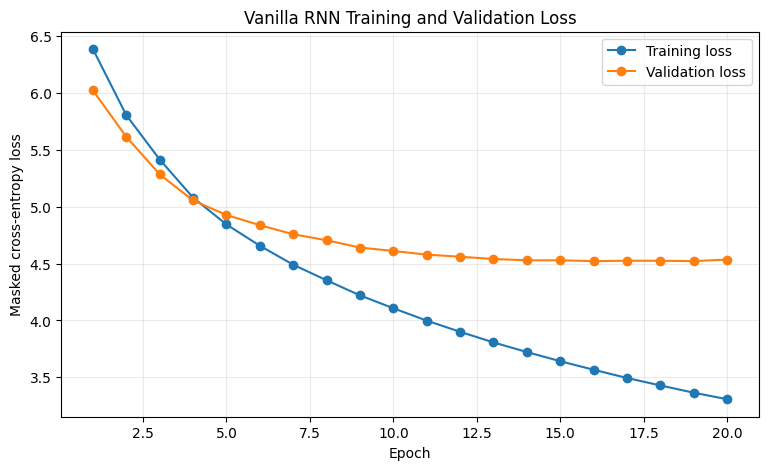

In [16]:
# ============================================================
# 15. TRAINING / VALIDATION CURVES
# ============================================================

history_df = pd.DataFrame(history)

history_df.index = np.arange(
    1,
    len(history_df) + 1
)

display(
    history_df.round(4)
)

plt.figure(figsize=(9, 5))

plt.plot(
    history_df.index,
    history_df["loss"],
    marker="o",
    label="Training loss"
)

plt.plot(
    history_df.index,
    history_df["val_loss"],
    marker="o",
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Masked cross-entropy loss")
plt.title(
    "Vanilla RNN Training and Validation Loss"
)

plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 8. Greedy English → Urdu translation

The trained model is now used on held-out test sentences. At each decoder step, the token with the highest predicted probability is selected.

In [17]:
# ============================================================
# 16. GREEDY DECODING
# ============================================================

def decode_ids(ids, id_to_token):

    tokens = []

    for idx in ids:

        idx = int(idx)
        token = id_to_token.get(
            idx,
            "<UNK>"
        )

        if token == "<EOS>":
            break

        if token not in SPECIALS:
            tokens.append(token)

    return " ".join(tokens)


def translate(sentence, max_steps=None):

    if max_steps is None:
        max_steps = MAX_UR_LEN - 1


    # Encode English input.
    source = np.full(
        (1, MAX_EN_LEN),
        PAD_ID,
        dtype=np.int32
    )

    encoded = encode_source(
        normalize_english(sentence),
        en_vocab
    )

    encoded = encoded[:MAX_EN_LEN]

    source[0, :len(encoded)] = encoded


    # Encoder.
    enc_embedding = model.encoder_embedding(
        tf.constant(source)
    )

    _, state = model.encoder_rnn(
        enc_embedding,
        training=False
    )


    # Start decoder with BOS.
    generated = [BOS_ID]


    for _ in range(max_steps):

        decoder_input = tf.constant(
            [[generated[-1]]],
            dtype=tf.int32
        )

        dec_embedding = model.decoder_embedding(
            decoder_input
        )

        decoder_output, state = model.decoder_rnn(
            dec_embedding,
            initial_state=state,
            training=False
        )

        probabilities = model.output_layer(
            decoder_output[:, -1, :]
        )

        next_id = int(
            tf.argmax(
                probabilities,
                axis=-1
            )[0].numpy()
        )

        generated.append(next_id)

        if next_id == EOS_ID:
            break


    return decode_ids(
        generated[1:],
        ur_id_to_token
    )


# Generate 10 qualitative examples.
sample_rows = test_df.sample(
    min(10, len(test_df)),
    random_state=SEED
)

results = []

for _, row in sample_rows.iterrows():

    prediction = translate(
        row["english"]
    )

    results.append({
        "English": row["english"],
        "Reference Urdu": row["urdu"],
        "Predicted Urdu": prediction
    })


qualitative_df = pd.DataFrame(results)

pd.set_option(
    "display.max_colwidth",
    120
)

display(qualitative_df)

,English,Reference Urdu,Predicted Urdu
0,and he said come and when peter was come down out of the ship he walked on the water to go to jesus,اس نے کہا آ ۔ پطرس کشتی سے اتر کر یسوع کے پاس جانے کے لئے پانی پر چلنے لگا ۔,اور اس نے ان سے کہا کیا تم نے مجھے دیا کہ وہ اس کے ساتھ ہے ۔
1,and the four and twenty elders which sat before god on their seats fell upon their faces and worshipped god,اور چوبیسوں بزرگوں نے جو خدا کے سامنے اپنے اپنے تخت پر بیٹھے تھے منہ کے بل گر کر خدا کو سجدہ کیا ۔,اور اس نے ان سے کہا کیا تم نے مجھے دیا کہ وہ اس کے ساتھ ہے ۔
2,verily verily i say unto you he that believeth on me the works that i do shall he do also and greater works than the...,مےیں تم سے سچ کہتا ہوں کہ جو مجھ پر ایمان رکھتا ہے یہ کام جو میں کرتا ہوں وہ بحی کرے گا بلکہ ان سے بھی بڑے کام کرے گ...,اور اس کے ساتھ اس کے ساتھ اس کے ساتھ رہے ۔
3,then jesus went with them and when he was now not far from the house the centurion sent friends to him saying unto h...,یسوع ان کے ساتھ چلا مگر جب وہ گھر کے قریب پہنچا تو صوبہ دار نے بعض دوستوں کی معرفت اسے یہ کہلا بھیجا کہ اے خداوند تک...,اور اس نے ان سے کہا کیا تم نے مجھے دیا کہ وہ اس کے ساتھ ہے ۔
4,finally brethren farewell be perfect be of good comfort be of one mind live in peace and the god of love and peace s...,غرض اے بھائیو خوش رہو ۔ کامل بنو ۔ خاطر جمع رکھّو ۔ یکدل رہو ۔ میل ملاپ رکھّو تو خدا محبّت اور میل ملاپ کا چشمہ تمہا...,اور اس نے ان سے کہا کیا تم نے مجھے دیا کہ وہ اس کے ساتھ ہے ۔
5,even so ye also outwardly appear righteous unto men but within ye are full of hypocrisy and iniquity,اسی طرح تم بھی ظاہر میں تو لوگوں کو راستباز دکھائی دیتے ہو مگر باطن میں ریاکاری اور بےدینی سے بھرے ہو ۔,اور اس کے ساتھ اس کے ساتھ اس کے ساتھ رہے ۔
6,be not overcome of evil but overcome evil with good,بدی سے مغلوب نہ ہو بلکہ نیکی کے زریعہ سے بدی پر غالب آؤ ۔,میں تم سے سچ کہتا ہوں کہ تم کو اس کے پاس آئے تو وہ اس کے ساتھ نہ ہو ۔
7,and he denied it again and a little after they that stood by said again to peter surely thou art one of them for tho...,مگر اس نے پھر انکار کیا اور تھوڑی دیر بعد انہوں نے جو پاس کھڑے تھے پطرس سے پھر کہا بیشک تو ان میں سے ہے کیونکہ تو گل...,اور اس نے ان سے کہا کیا تم نے مجھے دیا کہ وہ اس کے ساتھ ہے ۔
8,now the man out of whom the devils were departed besought him that he might be with him but jesus sent him away saying,لیکن جس شخص میں سے بد روحیں نکل گئی تھیں وہ اس کی منّت کرکے کہنے لگا کہ مجھے اپنے ساتھ رہنے دے مگر یسوع نے اسے رخصت ...,اور اس نے ان سے کہا کیا تم نے مجھے دیا کہ وہ اس کے ساتھ ہے ۔
9,and his disciples asked him saying what might this parable be,اس کے شاگردوں نے اس سے پوچھا کہ یہ تمثیل کیا ہے,اور اس نے ان سے کہا کیا تم نے مجھے دیا کہ وہ اس کے ساتھ ہے ۔


In [18]:
# ============================================================
# 17. FINAL HELD-OUT TEST LOSS
# ============================================================

test_losses = []

for (enc_x, dec_x), y, mask in test_ds:

    batch_loss = validation_step(
        enc_x,
        dec_x,
        y,
        mask
    )

    test_losses.append(
        float(batch_loss.numpy())
    )

test_loss = float(
    np.mean(test_losses)
)

print(
    f"Best validation loss: {best_val_loss:.4f}"
)

print(
    f"Test loss:            {test_loss:.4f}"
)

Best validation loss: 4.5215
Test loss:            4.5603


## 9. Final experiment summary

This table collects the main values needed for the technical report.

In [19]:
# ============================================================
# 18. ASSIGNMENT-READY SUMMARY
# ============================================================

summary = pd.DataFrame(
    [
        ["Dataset", DATASET_HANDLE],
        ["Random seed", SEED],
        ["Cleaned parallel pairs", len(df)],
        ["Training pairs", len(train_df)],
        ["Validation pairs", len(val_df)],
        ["Test pairs", len(test_df)],
        ["English vocabulary", len(en_vocab)],
        ["Urdu vocabulary", len(ur_vocab)],
        ["Max English sequence length", MAX_EN_LEN],
        ["Max Urdu sequence length", MAX_UR_LEN],
        ["Embedding dimension", EMBED_DIM],
        ["RNN hidden units", RNN_UNITS],
        ["Dropout", DROPOUT],
        ["Batch size", BATCH_SIZE],
        ["Learning rate", LEARNING_RATE],
        ["Gradient clipping", "Global norm = 1.0"],
        ["Best validation loss", round(best_val_loss, 4)],
        ["Test loss", round(test_loss, 4)]
    ],
    columns=["Item", "Value"]
)

display(summary)

print("\n✓ QUESTION 2 PIPELINE COMPLETED SUCCESSFULLY.")
print("✓ Dataset downloaded automatically from Kaggle.")
print("✓ No manual dataset attachment required.")
print("✓ Vanilla SimpleRNN encoder + decoder used.")
print("✓ Checkpoint saved at:", best_weights_path)

,Item,Value
0,Dataset,muhammadnoman76/translation-dataset
1,Random seed,42
2,Cleaned parallel pairs,8828
3,Training pairs,7062
4,Validation pairs,882
5,Test pairs,884
6,English vocabulary,6039
7,Urdu vocabulary,7182
8,Max English sequence length,40
9,Max Urdu sequence length,52



✓ QUESTION 2 PIPELINE COMPLETED SUCCESSFULLY.
✓ Dataset downloaded automatically from Kaggle.
✓ No manual dataset attachment required.
✓ Vanilla SimpleRNN encoder + decoder used.
✓ Checkpoint saved at: /kaggle/working/checkpoints/best_vanilla_rnn.weights.h5
